## Exploratory data analysis EDA

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("../data/processed/model_dataset.csv", parse_dates=["date"])

In [3]:
# print(df.head())
print(df.shape)
print(df.dtypes)
print(df.describe())

(2509, 18)
date                      datetime64[us]
sp500                            float64
vix                              float64
treasury_10y                     float64
treasury_2y                      float64
high_yield_spread                float64
return_1d                        float64
return_5d                        float64
volatility_5d                    float64
volatility_10d                   float64
volatility_20d                   float64
vix_change_1d                    float64
vix_change_5d                    float64
vix_vs_realized_vol              float64
yield_curve                      float64
treasury_10y_change_5d           float64
treasury_2y_change_5d            float64
target_volatility_5d             float64
dtype: object
                             date        sp500          vix  treasury_10y  \
count                        2509  2509.000000  2509.000000   2509.000000   
mean   2021-08-01 17:02:45.005978  4067.176010    18.607728      2.845460   
min   

### S&P 500 Index Over Time

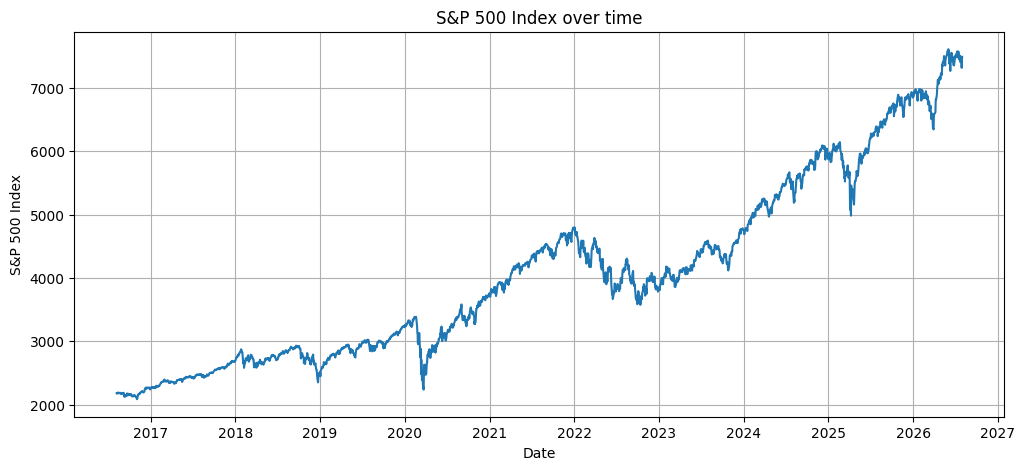

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sp500"])
plt.xlabel("Date")
plt.ylabel("S&P 500 Index")
plt.title("S&P 500 Index over time")
plt.grid()
plt.show()

The S&P 500 exhibits a clear long-term upward trend over the sample period, interrupted by several sharp drawdowns and recovery phases.

The most visible stress periods correspond to abrupt market declines, particularly during 2020 and again during later episodes of market turbulence. These drawdowns are followed by periods of recovery, illustrating that the index level itself is strongly non-stationary.

This supports the decision to avoid using the raw S&P 500 level as the main modelling signal. Instead, the project derives returns and rolling volatility measures, which are more suitable for modelling changes in market risk.

The plot also suggests that volatility is not constant through time: periods of rapid price declines appear substantially more unstable than periods of gradual market appreciation.

### Five-Day Forward Realised Volatility

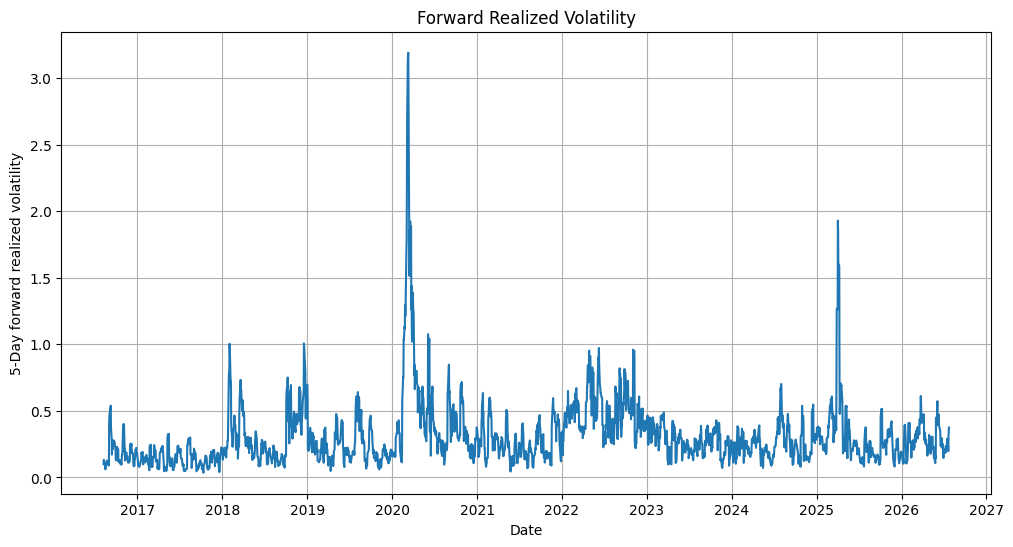

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["target_volatility_5d"])
plt.xlabel("Date")
plt.ylabel("5-Day forward realized volatility")
plt.title("Forward Realized Volatility")
plt.grid()
plt.show()

The five-day forward realised-volatility series is highly uneven through time.

Most observations remain at relatively low or moderate levels, while a small number of periods exhibit very large volatility spikes. The most extreme episode occurs around 2020, when annualised five-day realised volatility temporarily rises above 300%.

Other clusters of elevated volatility can also be observed around 2018–2019, 2022, and 2025.

This behaviour illustrates two important characteristics of financial volatility:

1. Volatility clustering: high-volatility observations tend to occur close to other high-volatility observations rather than being uniformly distributed through time.
2. Heavy-tailed behaviour: extreme volatility events are rare but considerably larger than typical observations.

These properties make forecasting challenging. A model that performs well during calm periods may still perform poorly during the relatively rare stress periods that are the most relevant from a risk-management perspective.

For this reason, model evaluation should not rely only on average forecasting error. Performance during high-volatility periods should also be evaluated separately.

### VIX vs Five-Day Forward Realised Volatility

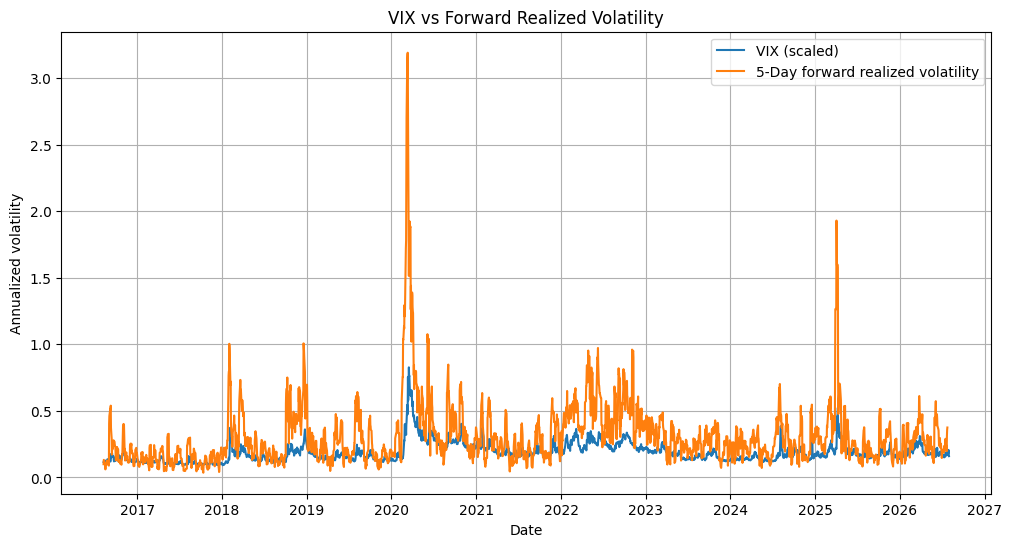

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["vix"]/100, label="VIX (scaled)")
plt.plot(df["date"], df["target_volatility_5d"], label="5-Day forward realized volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.title("VIX vs Forward Realized Volatility")
plt.legend()
plt.grid()
plt.show()

The VIX and subsequent five-day realised volatility display a clear visual relationship.

Periods of elevated VIX generally coincide with, or occur close to, periods of elevated realised volatility. This is particularly visible during large market-stress episodes, such as the volatility spike around 2020.

However, realised volatility is substantially more variable than the VIX. Several realised-volatility spikes exceed the corresponding VIX level, while the VIX evolves more smoothly.

This difference is consistent with the fact that the two variables represent different concepts:

* the **VIX** reflects volatility implied by S&P 500 option prices;
* `target_volatility_5d` measures volatility that is actually realised over the following five trading days.

The visual relationship suggests that the VIX may be an important predictor of future realised volatility, but the plot alone does not establish predictive performance. This hypothesis will therefore be tested quantitatively during model evaluation.

The gap between implied and recently realised volatility is also retained as an engineered feature through `vix_vs_realized_vol`, allowing the models to test whether disagreement between option-market expectations and recent realised volatility contains additional forecasting information.


### Distribution of Forward Realised Volatility



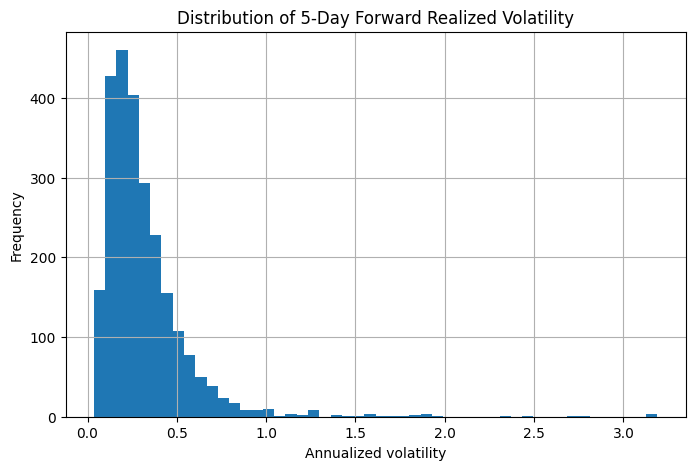

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["target_volatility_5d"].dropna(), bins=50)
plt.xlabel("Annualized volatility")
plt.ylabel("Frequency")
plt.title("Distribution of 5-Day Forward Realized Volatility")
plt.grid()
plt.show()

The distribution of the five-day forward realised-volatility target is strongly **right-skewed**.

Most observations are concentrated at relatively low or moderate volatility levels, while a small number of market-stress periods generate substantially larger values. The distribution therefore contains a long right tail, with a few observations reaching very high annualised volatility.

This confirms that market volatility is not normally distributed and that extreme volatility episodes, although rare, are economically important.

The shape of the target distribution has several implications for model evaluation:

* **Mean Absolute Error (MAE)** will be used as a primary regression metric because it is less dominated by a small number of extreme observations.
* **Root Mean Squared Error (RMSE)** will also be reported to measure the model's sensitivity to large forecasting errors.
* Forecasting performance will be evaluated separately during high-volatility periods to assess whether the model remains useful during market stress.

Extreme observations are retained rather than removed as outliers because they correspond to genuine periods of market turbulence and represent an important part of the forecasting problem.


return_5d                -0.372988
return_1d                -0.175482
vix_vs_realized_vol      -0.172226
treasury_2y_change_5d    -0.126921
yield_curve              -0.119411
treasury_10y             -0.107480
treasury_10y_change_5d   -0.088181
treasury_2y              -0.039895
vix_change_1d             0.122301
vix_change_5d             0.302438
volatility_20d            0.608636
volatility_10d            0.662159
volatility_5d             0.663471
vix                       0.726993
Name: target_volatility_5d, dtype: float64


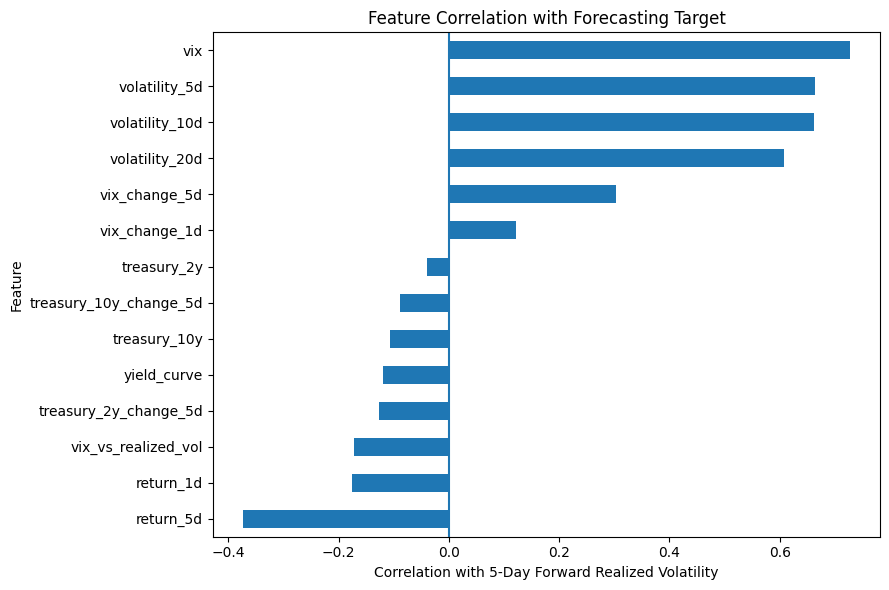

In [18]:
FEATURE_COLUMNS = [
    "vix",
    "treasury_10y",
    "treasury_2y",
    "return_1d",
    "return_5d",
    "volatility_5d",
    "volatility_10d",
    "volatility_20d",
    "vix_change_1d",
    "vix_change_5d",
    "vix_vs_realized_vol",
    "yield_curve",
    "treasury_10y_change_5d",
    "treasury_2y_change_5d",
]

correlations = (
    df[FEATURE_COLUMNS + ["target_volatility_5d"]]
    .corr()["target_volatility_5d"]
    .drop("target_volatility_5d")
    .sort_values()
)

print(correlations)

plt.figure(figsize=(9, 6))

correlations.plot(kind="barh")

plt.xlabel("Correlation with 5-Day Forward Realized Volatility")
plt.ylabel("Feature")
plt.title("Feature Correlation with Forecasting Target")

plt.axvline(0)

plt.tight_layout()
plt.show()

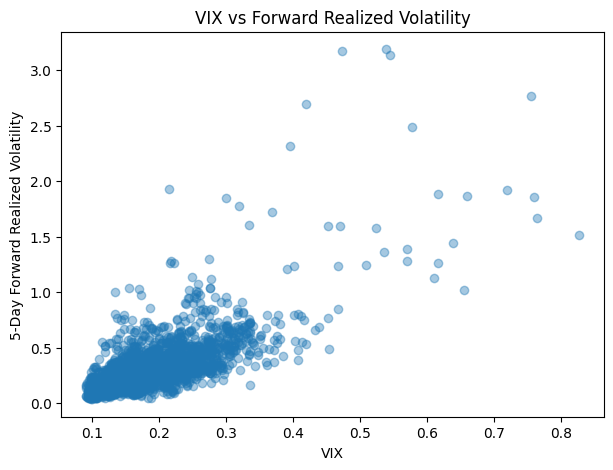

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["vix"] / 100,
    df["target_volatility_5d"],
    alpha=0.4,
)

plt.xlabel("VIX")
plt.ylabel("5-Day Forward Realized Volatility")
plt.title("VIX vs Forward Realized Volatility")

plt.show()

In [15]:
high_volatility = (
    df[
        [
            "date",
            "target_volatility_5d",
            "vix",
            "volatility_20d",
            "yield_curve",
        ]
    ]
    .sort_values(
        "target_volatility_5d",
        ascending=False,
    )
    .head(20)
)

print(high_volatility)

           date  target_volatility_5d    vix  volatility_20d  yield_curve
903  2020-03-11              3.190495  53.90        0.508433         0.32
902  2020-03-10              3.177740  47.30        0.487236         0.26
901  2020-03-09              3.135204  54.46        0.444935         0.16
904  2020-03-12              2.769043  75.47        0.595244         0.38
900  2020-03-06              2.701164  41.94        0.361528         0.25
905  2020-03-13              2.485006  57.83        0.700393         0.45
899  2020-03-05              2.320204  39.62        0.360369         0.33
2175 2025-04-02              1.929532  21.51        0.198993         0.29
909  2020-03-19              1.923966  72.00        0.863426         0.68
911  2020-03-23              1.885076  61.59        0.867584         0.48
910  2020-03-20              1.871470  66.04        0.868483         0.55
907  2020-03-17              1.861224  75.91        0.853555         0.55
2176 2025-04-03              1.848132 